In [4]:
import pandas as pd
import glob
import os



    我选择 UCSD ExtraSensory Dataset，因为它包含真实生活中的手机和智能手表传感器数据。我想研究用户睡觉时手机活动有什么变化，并判断这些传感器数据能否预测用户是否正在睡觉。


In [9]:
files = glob.glob("ExtraSensory/*.features_labels.csv.gz")
dfs = []
for file in files:
    temp = pd.read_csv(file, compression="gzip")

    filename = os.path.basename(file)
    temp["uuid"] = filename.split(".")[0]
    dfs.append(temp)
df = pd.concat(dfs, ignore_index=True)

In [10]:
df['uuid'].unique()#显示每一个人的id

array(['A7599A50-24AE-46A6-8EA6-2576F1011D81',
       '78A91A4E-4A51-4065-BDA7-94755F0BB3BB',
       '11B5EC4D-4133-4289-B475-4E737182A406',
       'CDA3BBF7-6631-45E8-85BA-EEB416B32A3C',
       'CF722AA9-2533-4E51-9FEB-9EAC84EE9AAC',
       '5152A2DF-FAF3-4BA8-9CA9-E66B32671A53',
       'A76A5AF5-5A93-4CF2-A16E-62353BB70E8A',
       '665514DE-49DC-421F-8DCB-145D0B2609AD',
       '83CF687B-7CEC-434B-9FE8-00C3D5799BE6',
       '27E04243-B138-4F40-A164-F40B60165CF3',
       '1538C99F-BA1E-4EFB-A949-6C7C47701B20',
       '5EF64122-B513-46AE-BCF1-E62AAC285D2C',
       '7D9BB102-A612-4E2A-8E22-3159752F55D8',
       '33A85C34-CFE4-4732-9E73-0A7AC861B27A',
       '74B86067-5D4B-43CF-82CF-341B76BEA0F4',
       '3600D531-0C55-44A7-AE95-A7A38519464E',
       '9DC38D04-E82E-4F29-AB52-B476535226F2',
       '5119D0F8-FCA8-4184-A4EB-19421A40DE0D',
       '7CE37510-56D0-4120-A1CF-0E23351428D2',
       '1DBB0F6F-1F81-4A50-9DF4-CD62ACFA4842',
       '1155FF54-63D3-4AB2-9863-8385D0BD0A13',
       '61359

In [13]:
#把 uuid 切换成No1 ,No2 ,No3

#每一行代表一次大约一分钟的记录；每个 column 是这一分钟内记录的某一种信息。

uuid_map = {
    old_uuid: f"No{i}"
    for i, old_uuid in enumerate(df["uuid"].unique(), start=1)
}

df["uuid"] = df["uuid"].map(uuid_map)

newdf = df[["uuid"] + [col for col in df.columns if col != "uuid"]]

In [14]:
newdf

,uuid,timestamp,raw_acc:magnitude_stats:mean,raw_acc:magnitude_stats:std,raw_acc:magnitude_stats:moment3,raw_acc:magnitude_stats:moment4,raw_acc:magnitude_stats:percentile25,raw_acc:magnitude_stats:percentile50,raw_acc:magnitude_stats:percentile75,raw_acc:magnitude_stats:value_entropy,...,label:STAIRS_-_GOING_DOWN,label:ELEVATOR,label:OR_standing,label:AT_SCHOOL,label:PHONE_IN_HAND,label:PHONE_IN_BAG,label:PHONE_ON_TABLE,label:WITH_CO-WORKERS,label:WITH_FRIENDS,label_source
0,No1,1446762297,1.057536,0.040597,-0.048977,0.124759,1.053158,1.057091,1.060935,0.344809,...,NaN,NaN,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2
1,No1,1446762357,1.057436,0.006165,-0.009415,0.018645,1.055086,1.057279,1.060143,1.014093,...,NaN,NaN,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2
2,No1,1446762417,1.056344,0.006302,-0.004635,0.013525,1.053282,1.056208,1.059165,1.429112,...,NaN,NaN,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2
3,No1,1446762487,1.056874,0.004767,-0.002796,0.007088,1.053958,1.057010,1.059996,2.190168,...,NaN,NaN,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2
4,No1,1446762548,1.057353,0.005415,0.006585,0.010781,1.054161,1.057100,1.059976,1.827865,...,NaN,NaN,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377341,No60,1438878506,0.035316,0.002927,0.002408,0.004441,0.033469,0.035112,0.037080,2.156580,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
377342,No60,1438878570,0.035231,0.003889,0.007480,0.012739,0.033350,0.035164,0.036809,1.161066,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
377343,No60,1438878660,0.035203,0.002709,0.002606,0.004813,0.033450,0.035044,0.036794,1.872454,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
377344,No60,1438878685,0.035113,0.002580,0.001801,0.003799,0.033404,0.035117,0.036749,2.120625,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1


In [65]:
#newdf.columns.tolist() 显示271个 features ，每个项检测的内容

In [45]:
#保留20列重要的feature ，和想要预测的结果 sleeping 

#1，EDA：睡觉和不睡觉时，加速度、屏幕亮度、位置、声音有什么区别？
#2,Missingness：label:SLEEPING 的缺失是否与 App 状态或电量有关？
#3,Hypothesis Test：睡觉和不睡觉时，手机加速度的平均值是否有显著差异？
#4,Prediction：根据时间和传感器数据预测用户是否睡觉。
#5,Fairness：模型对不同用户群体，或者白天与夜间记录，表现是否相同。

important_cols = [
    # 基本信息
    "uuid",
    "timestamp",

    # 手机加速度
    "raw_acc:magnitude_stats:mean",
    "raw_acc:magnitude_stats:std",
    "raw_acc:magnitude_stats:percentile50",
    "raw_acc:magnitude_stats:time_entropy",
    "raw_acc:magnitude_spectrum:spectral_entropy",
    "raw_acc:magnitude_autocorrelation:normalized_ac",

    # 手机陀螺仪
    "proc_gyro:magnitude_stats:std",

    # 位置
    "location:num_valid_updates",
    "location:diameter",
    "location:max_speed",

    # 环境声音
    "audio_naive:mfcc0:mean",
    "audio_properties:max_abs_value",

    # 手机使用状态
    "discrete:app_state:is_active",
    "lf_measurements:battery_level",
    "lf_measurements:screen_brightness",

    # 时间段
    "discrete:time_of_day:between0and6",
    "discrete:time_of_day:between21and3",
    # 要预测的标签
    "label:SLEEPING"
]

project_df = newdf[important_cols].copy()

In [46]:
project_df = df[important_cols].copy()

# 将 Unix timestamp 转换为圣地亚哥当地时间
project_df["datetime"] = (
    pd.to_datetime(
        project_df["timestamp"],
        unit="s",
        utc=True
    )
    .dt.tz_convert("America/Los_Angeles")
)

# 提取圣地亚哥当地小时
project_df["hour"] = project_df["datetime"].dt.hour

In [50]:
datetime = project_df.pop("datetime")
hour = project_df.pop("hour")

position = project_df.columns.get_loc("timestamp")

project_df.insert(position + 1, "datetime", datetime)
project_df.insert(position + 2, "hour", hour)
project_df

,uuid,timestamp,datetime,hour,raw_acc:magnitude_stats:mean,raw_acc:magnitude_stats:std,raw_acc:magnitude_stats:percentile50,raw_acc:magnitude_stats:time_entropy,raw_acc:magnitude_spectrum:spectral_entropy,raw_acc:magnitude_autocorrelation:normalized_ac,...,location:diameter,location:max_speed,audio_naive:mfcc0:mean,audio_properties:max_abs_value,discrete:app_state:is_active,lf_measurements:battery_level,lf_measurements:screen_brightness,discrete:time_of_day:between0and6,discrete:time_of_day:between21and3,label:SLEEPING
0,No1,1446762297,2015-11-05 14:24:57-08:00,14,1.057536,0.040597,1.057091,6.683838,0.431683,0.385890,...,0.802699,NaN,1.899699,9.092907,0.0,0.88,NaN,0.0,0.0,0.0
1,No1,1446762357,2015-11-05 14:25:57-08:00,14,1.057436,0.006165,1.057279,6.684595,0.429888,0.147357,...,1.920725,NaN,5.687659,7.802209,0.0,0.88,NaN,0.0,0.0,0.0
2,No1,1446762417,2015-11-05 14:26:57-08:00,14,1.056344,0.006302,1.056208,6.684594,0.430053,0.095604,...,0.358595,NaN,5.709549,8.083946,0.0,0.88,NaN,0.0,0.0,0.0
3,No1,1446762487,2015-11-05 14:28:07-08:00,14,1.056874,0.004767,1.057010,6.684602,0.429714,0.085321,...,2.765167,NaN,2.175165,9.097172,0.0,0.88,NaN,0.0,0.0,0.0
4,No1,1446762548,2015-11-05 14:29:08-08:00,14,1.057353,0.005415,1.057100,6.684599,0.429827,0.095939,...,1.866451,NaN,-1.658513,10.345220,0.0,0.88,NaN,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377341,No60,1438878506,2015-08-06 09:28:26-07:00,9,0.035316,0.002927,0.035112,6.681212,0.465250,0.261037,...,0.723632,NaN,6.007136,8.773694,0.0,0.96,NaN,0.0,0.0,NaN
377342,No60,1438878570,2015-08-06 09:29:30-07:00,9,0.035231,0.003889,0.035164,6.679400,0.468690,0.147205,...,0.850468,NaN,3.469494,9.917686,0.0,0.96,NaN,0.0,0.0,NaN
377343,No60,1438878660,2015-08-06 09:31:00-07:00,9,0.035203,0.002709,0.035044,6.681694,0.481864,0.108749,...,3.791793,NaN,1.904770,10.051476,0.0,0.96,NaN,0.0,0.0,NaN
377344,No60,1438878685,2015-08-06 09:31:25-07:00,9,0.035113,0.002580,0.035117,6.681923,0.468361,0.202202,...,0.962207,NaN,3.188693,9.826930,0.0,0.96,NaN,0.0,0.0,NaN


In [54]:
#project_df.to_csv("project_df.csv", index=False)
project_df

,uuid,timestamp,datetime,hour,raw_acc:magnitude_stats:mean,raw_acc:magnitude_stats:std,raw_acc:magnitude_stats:percentile50,raw_acc:magnitude_stats:time_entropy,raw_acc:magnitude_spectrum:spectral_entropy,raw_acc:magnitude_autocorrelation:normalized_ac,...,location:diameter,location:max_speed,audio_naive:mfcc0:mean,audio_properties:max_abs_value,discrete:app_state:is_active,lf_measurements:battery_level,lf_measurements:screen_brightness,discrete:time_of_day:between0and6,discrete:time_of_day:between21and3,label:SLEEPING
0,No1,1446762297,2015-11-05 14:24:57-08:00,14,1.057536,0.040597,1.057091,6.683838,0.431683,0.385890,...,0.802699,NaN,1.899699,9.092907,0.0,0.88,NaN,0.0,0.0,0.0
1,No1,1446762357,2015-11-05 14:25:57-08:00,14,1.057436,0.006165,1.057279,6.684595,0.429888,0.147357,...,1.920725,NaN,5.687659,7.802209,0.0,0.88,NaN,0.0,0.0,0.0
2,No1,1446762417,2015-11-05 14:26:57-08:00,14,1.056344,0.006302,1.056208,6.684594,0.430053,0.095604,...,0.358595,NaN,5.709549,8.083946,0.0,0.88,NaN,0.0,0.0,0.0
3,No1,1446762487,2015-11-05 14:28:07-08:00,14,1.056874,0.004767,1.057010,6.684602,0.429714,0.085321,...,2.765167,NaN,2.175165,9.097172,0.0,0.88,NaN,0.0,0.0,0.0
4,No1,1446762548,2015-11-05 14:29:08-08:00,14,1.057353,0.005415,1.057100,6.684599,0.429827,0.095939,...,1.866451,NaN,-1.658513,10.345220,0.0,0.88,NaN,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377341,No60,1438878506,2015-08-06 09:28:26-07:00,9,0.035316,0.002927,0.035112,6.681212,0.465250,0.261037,...,0.723632,NaN,6.007136,8.773694,0.0,0.96,NaN,0.0,0.0,NaN
377342,No60,1438878570,2015-08-06 09:29:30-07:00,9,0.035231,0.003889,0.035164,6.679400,0.468690,0.147205,...,0.850468,NaN,3.469494,9.917686,0.0,0.96,NaN,0.0,0.0,NaN
377343,No60,1438878660,2015-08-06 09:31:00-07:00,9,0.035203,0.002709,0.035044,6.681694,0.481864,0.108749,...,3.791793,NaN,1.904770,10.051476,0.0,0.96,NaN,0.0,0.0,NaN
377344,No60,1438878685,2015-08-06 09:31:25-07:00,9,0.035113,0.002580,0.035117,6.681923,0.468361,0.202202,...,0.962207,NaN,3.188693,9.826930,0.0,0.96,NaN,0.0,0.0,NaN


In [52]:
#查看每一个 column的 miss比例
for col in project_df.columns:
    print(project_df[col].isna().mean())

#删除location:max_speed
project_df = project_df.drop(
    columns=["location:max_speed"]
)


0.0
0.0
0.0
0.0
0.0007685254381920041
0.0007685254381920041
0.0007685254381920041
0.0007685254381920041
0.0007685254381920041
0.0007685254381920041
0.046201629273928964
0.11504560800962511
0.11504560800962511
0.722988980935269
0.02542494156556582
0.0195920984984603
0.0
0.0008453779820112046
0.41446576881694785
0.0
0.0
0.24401477688911502


    location:max_speed 缺失 72.3%，太高。
    screen_brightness 缺失 41.45%，可以暂时保留，但需要谨慎使用。
    label:SLEEPING 缺失 24.4%，后面需要专门分析。
    其他大部分特征缺失程度可以接受。

In [56]:
#增加is_night列
#目的：将具体小时转换成更容易研究和解释的“夜间/非夜间”变量。
project_df["is_night"] = (
    (project_df["hour"] >= 21) |
    (project_df["hour"] < 6)
).astype(int)

In [61]:
#所有sleeping占总数据的比例
project_df['label:SLEEPING'].mean()


np.float64(0.2911472720389248)

In [71]:
#双变量图1：不同小时的睡眠比例
hourly_sleep = (
    project_df
    .dropna(subset=["label:SLEEPING"])
    .groupby("hour")["label:SLEEPING"]
    .mean()
    .reset_index(name="sleep_rate")
)

fig = px.line(
    hourly_sleep,
    x="hour",
    y="sleep_rate",
    markers=True,
    labels={
        "hour": "Hour of Day",
        "sleep_rate": "Proportion Sleeping"
    },
    title="Sleep Rate by Hour of Day"
)

#fig.show()

In [66]:
print("Shape:", project_df.shape)
print("Number of users:", project_df["uuid"].nunique())
print("Duplicate rows:", project_df.duplicated().sum())
print(
    "Duplicate user-timestamps:",
    project_df.duplicated(["uuid", "timestamp"]).sum()
)


Shape: (377346, 22)
Number of users: 60
Duplicate rows: 0
Duplicate user-timestamps: 0


In [68]:
#了解 label:SLEEPING 中睡觉、不睡觉和缺失的数据量。
sleep_counts = project_df["label:SLEEPING"].value_counts(
    dropna=False
)

sleep_counts


label:SLEEPING
0.0    202213
NaN     92078
1.0     83055
Name: count, dtype: int64

    202,213 条记录表示用户没有睡觉。
    83,055 条记录表示用户正在睡觉。
    92,078 条记录没有明确的睡眠标签。
    目前先不要删除 NaN，因为后面需要进行 missingness analysis。

In [69]:
project_df["label:SLEEPING"].dropna().unique()

array([0., 1.])

决定哪些 columns 可以保留，哪些不适合用于主要分析。

## Introduction and Question Identification

The ExtraSensory dataset contains smartphone and smartwatch sensor measurements collected from 60 users during their normal daily lives. The application automatically recorded approximately 20 seconds of sensor data every minute. The dataset includes information about phone movement, location, audio, phone activity, battery level, screen brightness, and user-reported behavioral labels.

This project focuses on the question: **How does smartphone activity differ when users are sleeping versus not sleeping?** Understanding this relationship may help mobile devices recognize sleep automatically without requiring users to manually report their behavior.

The response variable of interest is `label:SLEEPING`, where 1 indicates that the user was sleeping, 0 indicates that the user was not sleeping, and a missing value means that the user's sleep status was unknown.

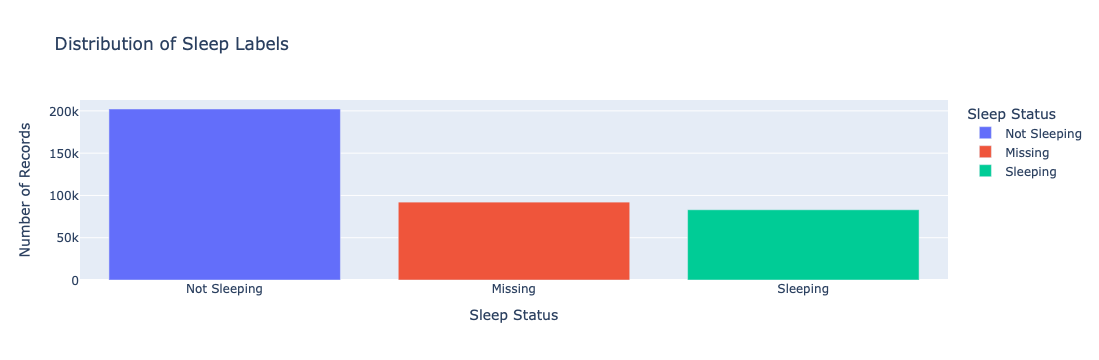

In [72]:
sleep_plot_df = (
    project_df["label:SLEEPING"]
    .map({
        0: "Not Sleeping",
        1: "Sleeping"
    })
    .fillna("Missing")
    .value_counts()
    .rename_axis("Sleep Status")
    .reset_index(name="Count")
)

fig = px.bar(
    sleep_plot_df,
    x="Sleep Status",
    y="Count",
    color="Sleep Status",
    title="Distribution of Sleep Labels",
    labels={
        "Sleep Status": "Sleep Status",
        "Count": "Number of Records"
    }
)

fig.show()

In [75]:
#制作 Checkpoint 1 要展示的双变量图
hourly_sleep = (
    project_df
    .dropna(subset=["label:SLEEPING"])
    .groupby("hour")["label:SLEEPING"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={
        "mean": "sleep_rate",
        "count": "number_of_records"
    })
)

hourly_sleep

,hour,sleep_rate,number_of_records
0,0,0.674871,11986
1,1,0.801372,11665
2,2,0.852452,11420
3,3,0.877093,10927
4,4,0.894607,10513
5,5,0.876722,9945
6,6,0.695743,10031
7,7,0.498025,9875
8,8,0.287902,10382
9,9,0.123172,11212


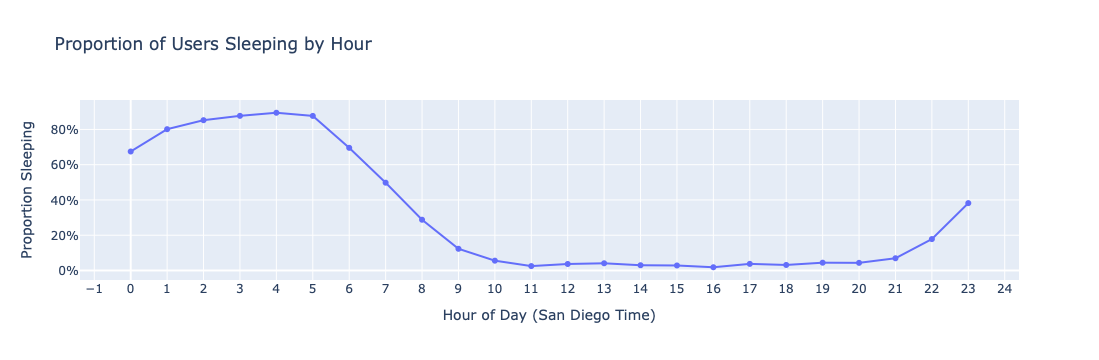

In [74]:
fig = px.line(
    hourly_sleep,
    x="hour",
    y="sleep_rate",
    markers=True,
    title="Proportion of Users Sleeping by Hour",
    labels={
        "hour": "Hour of Day (San Diego Time)",
        "sleep_rate": "Proportion Sleeping"
    }
)

fig.update_xaxes(dtick=1)
fig.update_yaxes(tickformat=".0%")

fig.show()

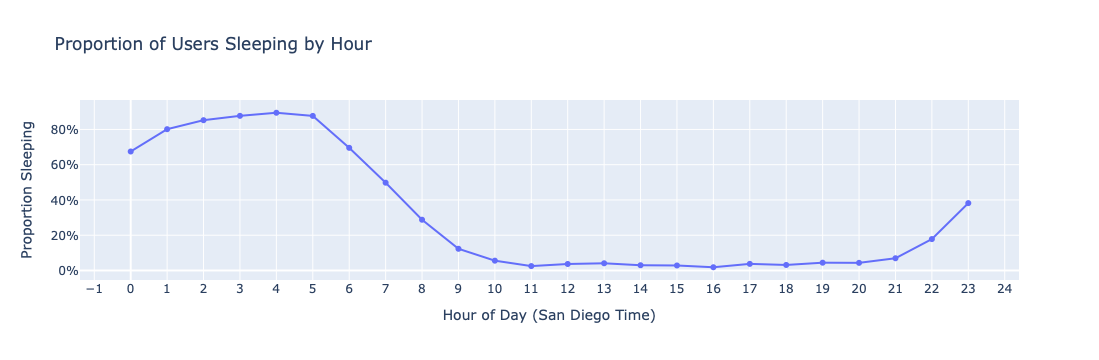

In [76]:
fig = px.line(
    hourly_sleep,
    x="hour",
    y="sleep_rate",
    markers=True,
    title="Proportion of Users Sleeping by Hour",
    labels={
        "hour": "Hour of Day (San Diego Time)",
        "sleep_rate": "Proportion Sleeping"
    }
)

fig.update_xaxes(dtick=1)
fig.update_yaxes(tickformat=".0%")

fig.show()